# 1. Limpieza de Datos

## Importación de librerías y carga del dataset

In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
df = pd.read_csv('data/Titanic-Dataset.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Valores nulos por columna")
print(df.isnull().sum())

Valores nulos por columna
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
print(f"El shape del conjunto de entrenamiento es {df.shape}. {df.shape[0]} filas y {df.shape[1]} columnas.") 

El shape del conjunto de entrenamiento es (891, 12). 891 filas y 12 columnas.


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## Revisión de valores faltantes

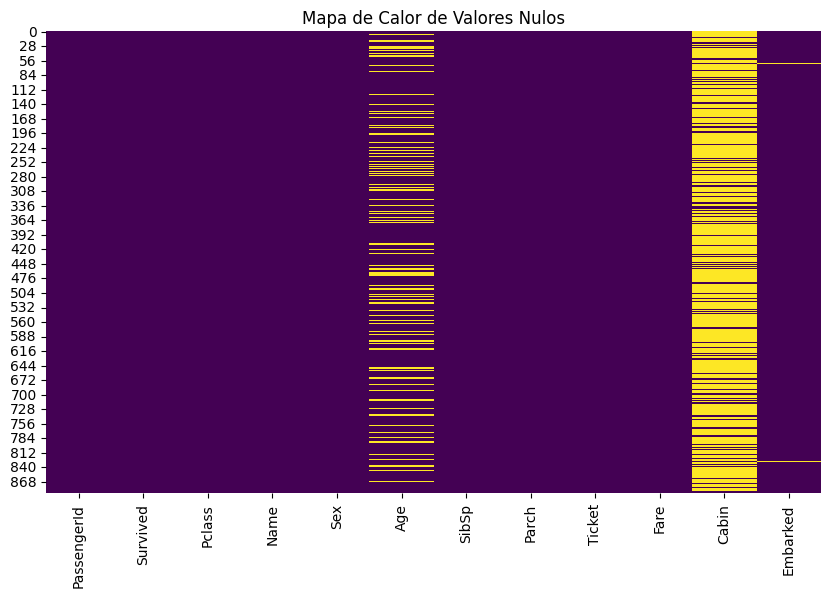

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title('Mapa de Calor de Valores Nulos')

# Guardar el gráfico como un archivo PNG
plt.savefig('outputs/mapadecalor_valoresnulos.png', format='png')

# Mostrar el gráfico
plt.show()

In [8]:
missing_values_percentage = df.isnull().mean() * 100
missing_values_percentage = missing_values_percentage.round(2).sort_values(ascending=False)
print(missing_values_percentage)

Cabin          77.10
Age            19.87
Embarked        0.22
PassengerId     0.00
Name            0.00
Pclass          0.00
Survived        0.00
Sex             0.00
Parch           0.00
SibSp           0.00
Fare            0.00
Ticket          0.00
dtype: float64


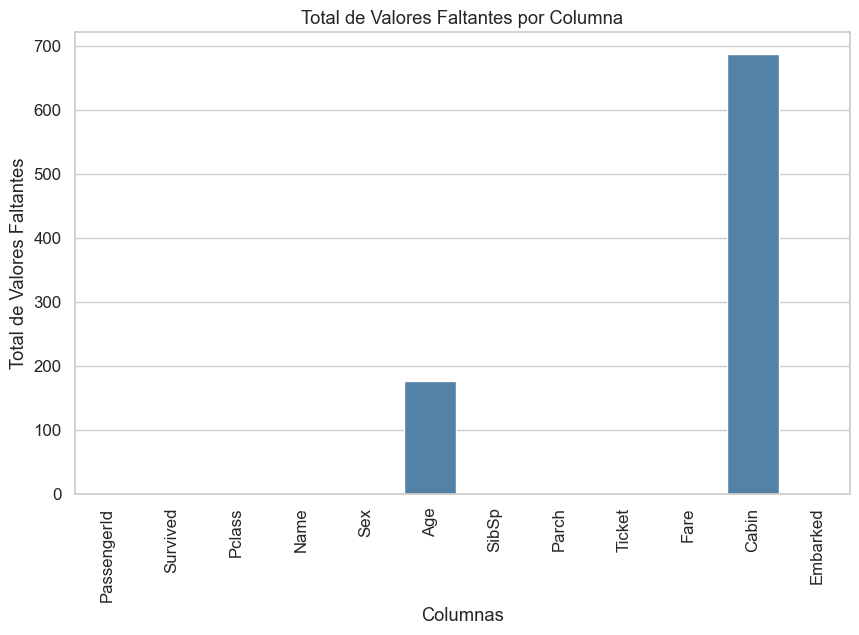

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular valores faltantes por columna
missing_values = df.isnull().sum()

# Configurar estilo
sns.set(style="whitegrid", font_scale=1.1)

# Crear gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, color='steelblue')

# Personalizar etiquetas y título
plt.title('Total de Valores Faltantes por Columna')
plt.xlabel('Columnas')
plt.ylabel('Total de Valores Faltantes')
plt.xticks(rotation=90)

# Mostrar gráfico
plt.show()


  ## Imputación de valores faltantes

In [10]:
# Crear copia del DataFrame original
df_clean = df.copy()

# Eliminar columna 'Cabin'
df_clean.drop('Cabin', axis=1, inplace=True)

# Imputar valores faltantes en 'Age' con la mediana
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# Imputar valores faltantes en 'Embarked' con la moda
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

df_clean.info()



<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [11]:
# Eliminar columnas irrelevantes
df_clean.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

# Verificar que ya no estén
print(df_clean.columns)

print(f"\nDespués de limpiar df: {df_clean.shape[0]} filas y {df_clean.shape[1]} columnas.")

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='str')

Después de limpiar df: 891 filas y 8 columnas.


In [12]:
df_clean.to_csv('data/titanic_clean.csv', index=False)
print("Datos guardados en data/titanic_clean.csv")

Datos guardados en data/titanic_clean.csv
